In [1]:
# ── Core Libraries ────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Preprocessing ─────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# ── Classification Models ─────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ── Evaluation Metrics ────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)

# ── Settings ──────────────────────────────────────────────────
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

print("✓ Libraries imported successfully.")

✓ Libraries imported successfully.


In [3]:
import urllib.request
import zipfile
import os

# Download the dataset directly from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
zip_path = "bank-additional.zip"

print("Downloading dataset...")
urllib.request.urlretrieve(url, zip_path)

print("Extracting...")
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(".")

# Load the full dataset
df = pd.read_csv('bank-additional/bank-additional-full.csv', sep=';')

print("✓ Dataset loaded successfully!")
print("\nDataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Extracting...
✓ Dataset loaded successfully!

Dataset Shape: (41188, 21)

First 5 rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"\nRows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\n--- Column Names & Data Types ---")
print(df.dtypes)

print("\n--- Missing Values ---")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✓ No missing values found.")

print("\n--- Target Variable Distribution ---")
print(df['y'].value_counts())
print(f"\nClass Balance:")
print(df['y'].value_counts(normalize=True).map(lambda x: f"{x*100:.2f}%"))

DATASET OVERVIEW

Rows    : 41188
Columns : 21

--- Column Names & Data Types ---
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

--- Missing Values ---
✓ No missing values found.

--- Target Variable Distribution ---
y
no     36548
yes     4640
Name: count, dtype: int64

Class Balance:
y
no     88.73%
yes    11.27%
Name: proportion, dtype: object


/tmp/ipykernel_33456/2031105729.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='y', palette=['steelblue', 'coral'])


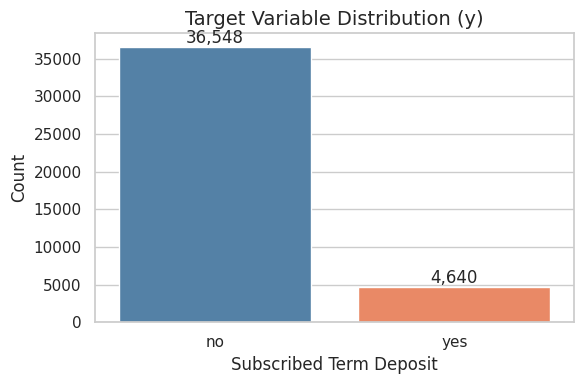

In [6]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='y', palette=['steelblue', 'coral'])
plt.title("Target Variable Distribution (y)", fontsize=14)
plt.xlabel("Subscribed Term Deposit")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

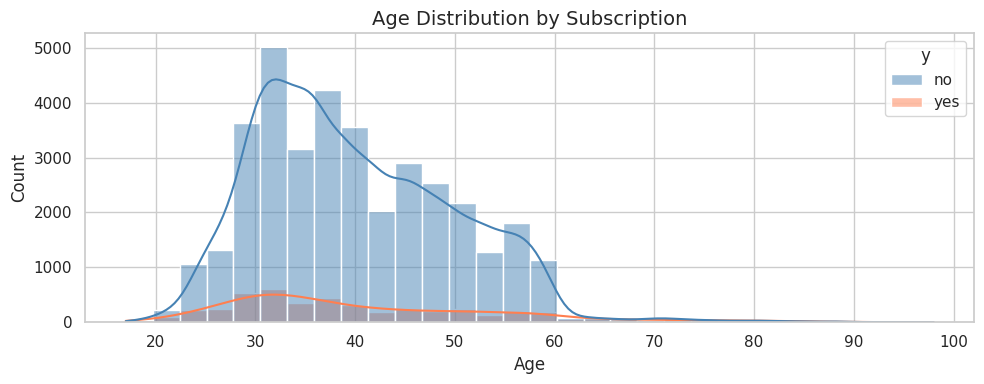

In [7]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='age', hue='y', bins=30, kde=True,
             palette=['steelblue', 'coral'])
plt.title("Age Distribution by Subscription", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

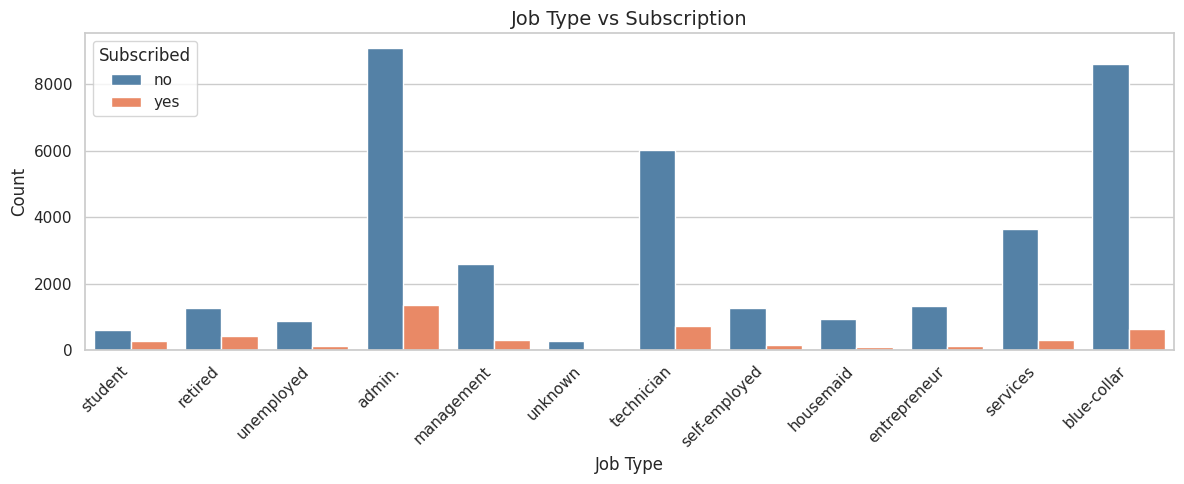

In [8]:
plt.figure(figsize=(12, 5))
job_order = df.groupby('job')['y'].apply(
    lambda x: (x == 'yes').mean()
).sort_values(ascending=False).index

sns.countplot(data=df, x='job', hue='y',
              order=job_order, palette=['steelblue', 'coral'])
plt.title("Job Type vs Subscription", fontsize=14)
plt.xlabel("Job Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subscribed')
plt.tight_layout()
plt.show()

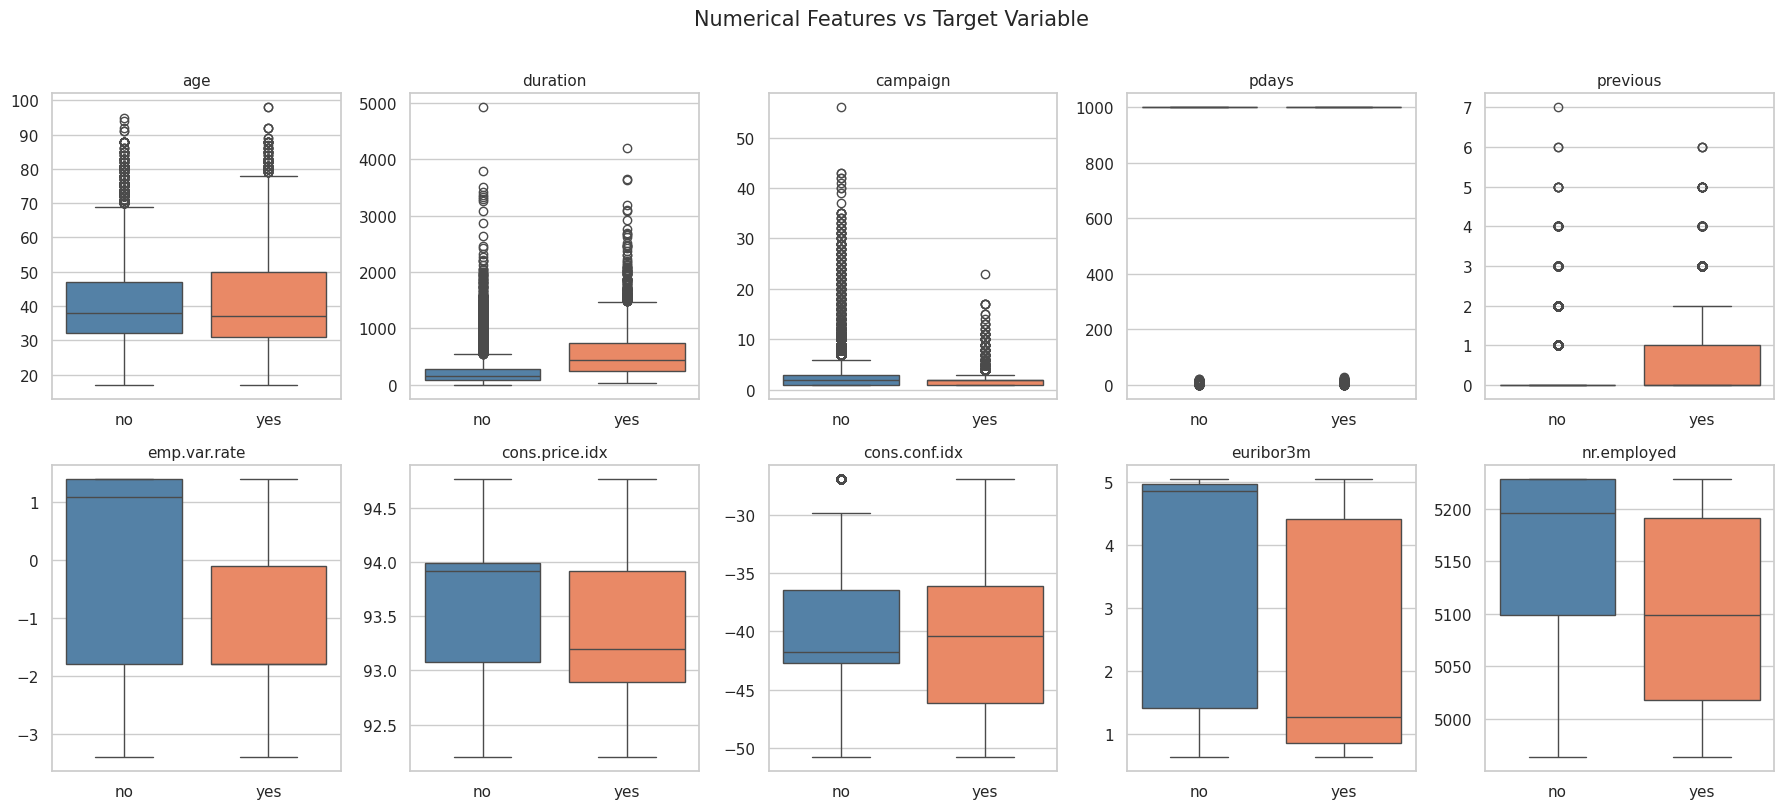

In [10]:
num_cols = ['age', 'duration', 'campaign', 'pdays',
            'previous', 'emp.var.rate', 'cons.price.idx',
            'cons.conf.idx', 'euribor3m', 'nr.employed']

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='y', y=col,
                hue='y', palette=['steelblue', 'coral'],
                legend=False, ax=axes[i])
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.suptitle("Numerical Features vs Target Variable", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

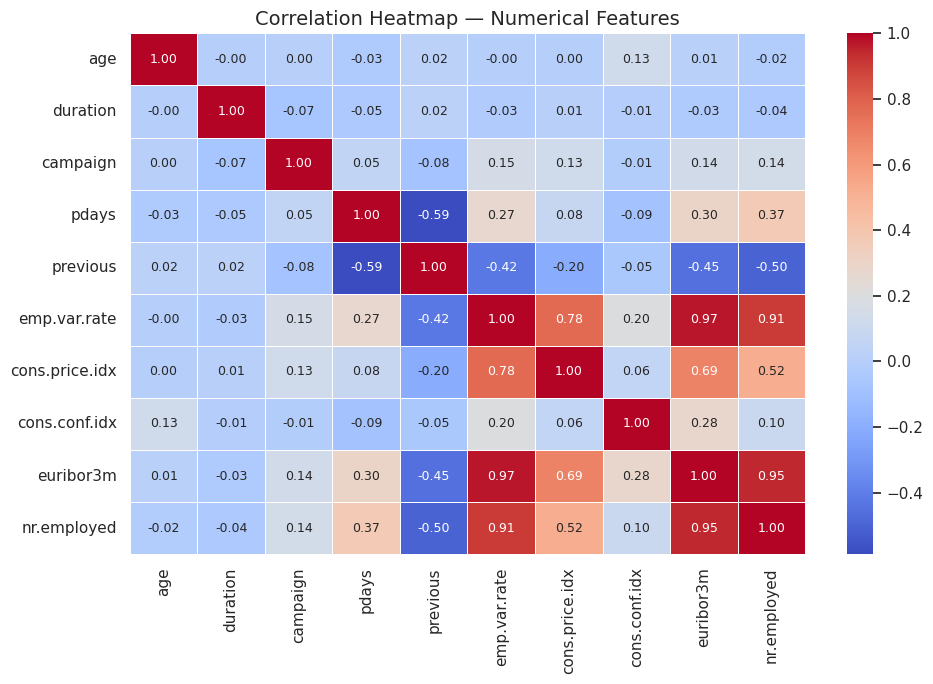

In [11]:
num_cols = ['age', 'duration', 'campaign', 'pdays',
            'previous', 'emp.var.rate', 'cons.price.idx',
            'cons.conf.idx', 'euribor3m', 'nr.employed']

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size": 9}
)
plt.title("Correlation Heatmap — Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
print("=" * 50)
print("DATA PREPROCESSING")
print("=" * 50)

# ── Step 1: Copy original dataframe ──────────────────────────
df_clean = df.copy()

# ── Step 2: Encode target variable ───────────────────────────
df_clean['y'] = df_clean['y'].map({'no': 0, 'yes': 1})
print(f"\n✓ Target encoded → no=0, yes=1")
print(f"  Class counts: {df_clean['y'].value_counts().to_dict()}")

# ── Step 3: One-hot encode all categorical columns ────────────
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print(f"\n✓ Categorical columns to encode ({len(cat_cols)}):")
print(f"  {cat_cols}")

df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
print(f"\n✓ After encoding — Shape: {df_clean.shape}")

# ── Step 4: Define X and y ────────────────────────────────────
X = df_clean.drop(columns=['y'])
y = df_clean['y']

print(f"\n✓ Features (X) shape : {X.shape}")
print(f"✓ Target  (y) shape  : {y.shape}")

# ── Step 5: Train/Test split — 70% / 30% ─────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"\n✓ Train/Test Split (70/30):")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train class balance:")
print(f"  {y_train.value_counts(normalize=True).map(lambda x: f'{x*100:.2f}%').to_dict()}")

# ── Step 6: Feature Scaling ───────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n✓ Feature scaling applied (StandardScaler)")
print(f"\n✓ Preprocessing complete!")

DATA PREPROCESSING

✓ Target encoded → no=0, yes=1
  Class counts: {0: 36548, 1: 4640}

✓ Categorical columns to encode (10):
  ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

✓ After encoding — Shape: (41188, 54)

✓ Features (X) shape : (41188, 53)
✓ Target  (y) shape  : (41188,)

✓ Train/Test Split (70/30):
  X_train : (28831, 53)
  X_test  : (12357, 53)
  y_train class balance:
  {0: '88.73%', 1: '11.27%'}

✓ Feature scaling applied (StandardScaler)

✓ Preprocessing complete!


In [13]:
# ── Results storage ───────────────────────────────────────────
results_list = []

# ── Confusion Matrix Plot ─────────────────────────────────────
def plot_confusion_matrix(model_name, y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No', 'Yes'],
                yticklabels=['No', 'Yes'],
                annot_kws={"size": 13})
    plt.title(f'Confusion Matrix — {model_name}', fontsize=13)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

# ── Full Evaluation Function ──────────────────────────────────
def evaluate_model(model, model_name, X_test, y_test, y_pred):
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  AUC       : {auc:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=['No', 'Yes']))

    # Confusion Matrix
    plot_confusion_matrix(model_name, y_test, y_pred)

    # Store results
    results_list.append({
        "Model":     model_name,
        "Accuracy":  round(acc,  4),
        "Precision": round(prec, 4),
        "Recall":    round(rec,  4),
        "F1 Score":  round(f1,   4),
        "AUC":       round(auc,  4)
    })

    return auc, model.predict_proba(X_test)[:, 1]

# ── ROC curve storage for combined plot ───────────────────────
roc_data = {}

print("✓ Helper functions defined successfully.")

✓ Helper functions defined successfully.


Training Logistic Regression...

  Logistic Regression
  Accuracy  : 0.9120
  Precision : 0.6743
  Recall    : 0.4224
  F1 Score  : 0.5194
  AUC       : 0.9383

  Classification Report:
              precision    recall  f1-score   support

          No       0.93      0.97      0.95     10965
         Yes       0.67      0.42      0.52      1392

    accuracy                           0.91     12357
   macro avg       0.80      0.70      0.74     12357
weighted avg       0.90      0.91      0.90     12357



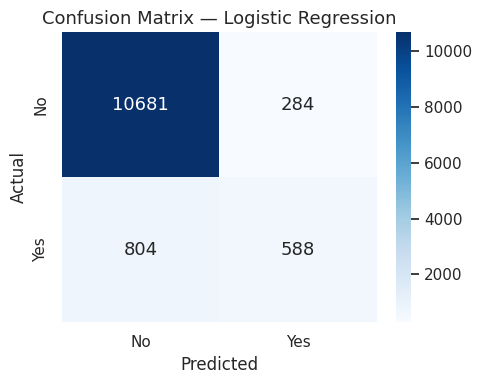

In [14]:
print("Training Logistic Regression...")

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

auc_lr, prob_lr = evaluate_model(
    lr_model, "Logistic Regression",
    X_test_scaled, y_test, y_pred_lr
)

# Store ROC data
roc_data["Logistic Regression"] = (auc_lr, prob_lr)

Training Logistic Regression...

  Logistic Regression
  Accuracy  : 0.9120
  Precision : 0.6743
  Recall    : 0.4224
  F1 Score  : 0.5194
  AUC       : 0.9383

  Classification Report:
              precision    recall  f1-score   support

          No       0.93      0.97      0.95     10965
         Yes       0.67      0.42      0.52      1392

    accuracy                           0.91     12357
   macro avg       0.80      0.70      0.74     12357
weighted avg       0.90      0.91      0.90     12357



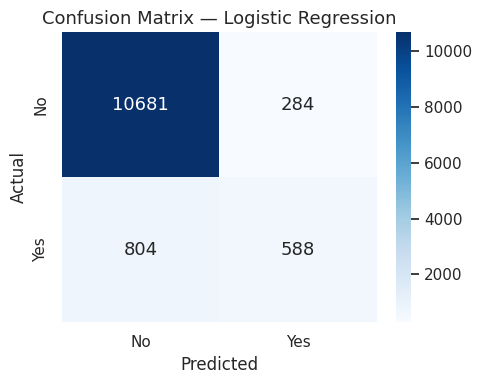

In [15]:
print("Training Logistic Regression...")

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

auc_lr, prob_lr = evaluate_model(
    lr_model, "Logistic Regression",
    X_test_scaled, y_test, y_pred_lr
)

roc_data["Logistic Regression"] = (auc_lr, prob_lr)

Training Naive Bayes...

  Naive Bayes
  Accuracy  : 0.7569
  Precision : 0.2924
  Recall    : 0.8154
  F1 Score  : 0.4304
  AUC       : 0.8454

  Classification Report:
              precision    recall  f1-score   support

          No       0.97      0.75      0.85     10965
         Yes       0.29      0.82      0.43      1392

    accuracy                           0.76     12357
   macro avg       0.63      0.78      0.64     12357
weighted avg       0.89      0.76      0.80     12357



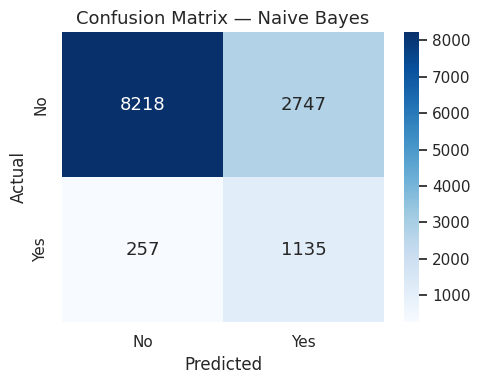

In [16]:
print("Training Naive Bayes...")

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred_nb = nb_model.predict(X_test_scaled)

auc_nb, prob_nb = evaluate_model(
    nb_model, "Naive Bayes",
    X_test_scaled, y_test, y_pred_nb
)

roc_data["Naive Bayes"] = (auc_nb, prob_nb)

Training K-Nearest Neighbors...

  K-Nearest Neighbors
  Accuracy  : 0.9011
  Precision : 0.6142
  Recall    : 0.3283
  F1 Score  : 0.4279
  AUC       : 0.8191

  Classification Report:
              precision    recall  f1-score   support

          No       0.92      0.97      0.95     10965
         Yes       0.61      0.33      0.43      1392

    accuracy                           0.90     12357
   macro avg       0.77      0.65      0.69     12357
weighted avg       0.89      0.90      0.89     12357



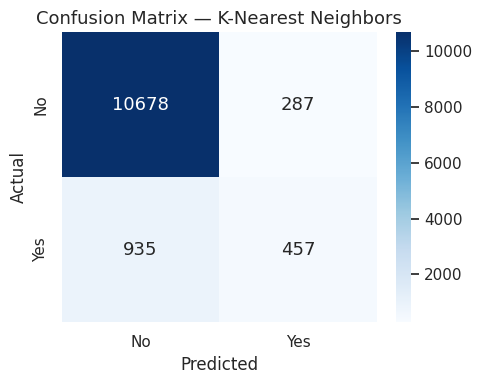

In [17]:
print("Training K-Nearest Neighbors...")

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

auc_knn, prob_knn = evaluate_model(
    knn_model, "K-Nearest Neighbors",
    X_test_scaled, y_test, y_pred_knn
)

roc_data["K-Nearest Neighbors"] = (auc_knn, prob_knn)

Training Decision Tree...

  Decision Tree
  Accuracy  : 0.8900
  Precision : 0.5115
  Recall    : 0.5280
  F1 Score  : 0.5196
  AUC       : 0.7320

  Classification Report:
              precision    recall  f1-score   support

          No       0.94      0.94      0.94     10965
         Yes       0.51      0.53      0.52      1392

    accuracy                           0.89     12357
   macro avg       0.73      0.73      0.73     12357
weighted avg       0.89      0.89      0.89     12357



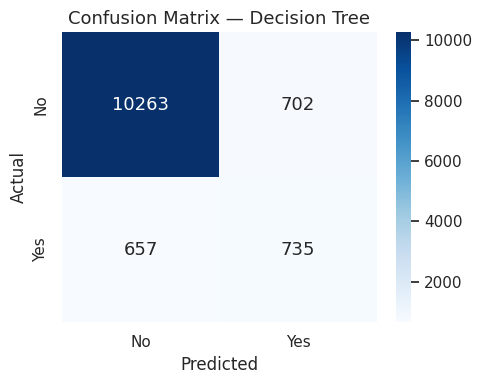

In [18]:
print("Training Decision Tree...")

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

auc_dt, prob_dt = evaluate_model(
    dt_model, "Decision Tree",
    X_test_scaled, y_test, y_pred_dt
)

roc_data["Decision Tree"] = (auc_dt, prob_dt)

Training Random Forest...

  Random Forest
  Accuracy  : 0.9158
  Precision : 0.6739
  Recall    : 0.4885
  F1 Score  : 0.5664
  AUC       : 0.9438

  Classification Report:
              precision    recall  f1-score   support

          No       0.94      0.97      0.95     10965
         Yes       0.67      0.49      0.57      1392

    accuracy                           0.92     12357
   macro avg       0.81      0.73      0.76     12357
weighted avg       0.91      0.92      0.91     12357



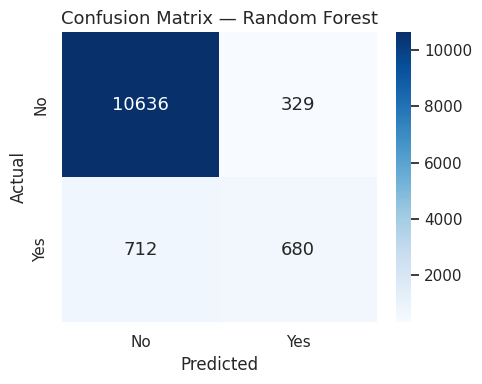

In [19]:
print("Training Random Forest...")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

auc_rf, prob_rf = evaluate_model(
    rf_model, "Random Forest",
    X_test_scaled, y_test, y_pred_rf
)

roc_data["Random Forest"] = (auc_rf, prob_rf)

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:23:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  XGBoost
  Accuracy  : 0.9141
  Precision : 0.6383
  Recall    : 0.5489
  F1 Score  : 0.5902
  AUC       : 0.9453

  Classification Report:
              precision    recall  f1-score   support

          No       0.94      0.96      0.95     10965
         Yes       0.64      0.55      0.59      1392

    accuracy                           0.91     12357
   macro avg       0.79      0.75      0.77     12357
weighted avg       0.91      0.91      0.91     12357



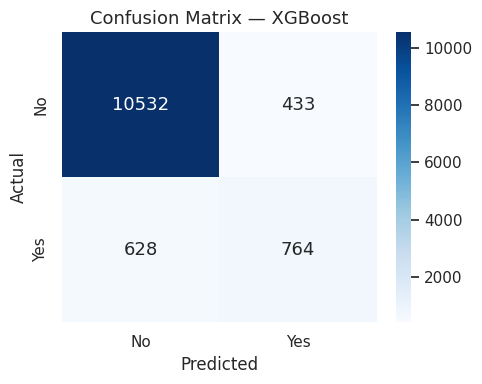

In [20]:
print("Training XGBoost...")

xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

auc_xgb, prob_xgb = evaluate_model(
    xgb_model, "XGBoost",
    X_test_scaled, y_test, y_pred_xgb
)

roc_data["XGBoost"] = (auc_xgb, prob_xgb)

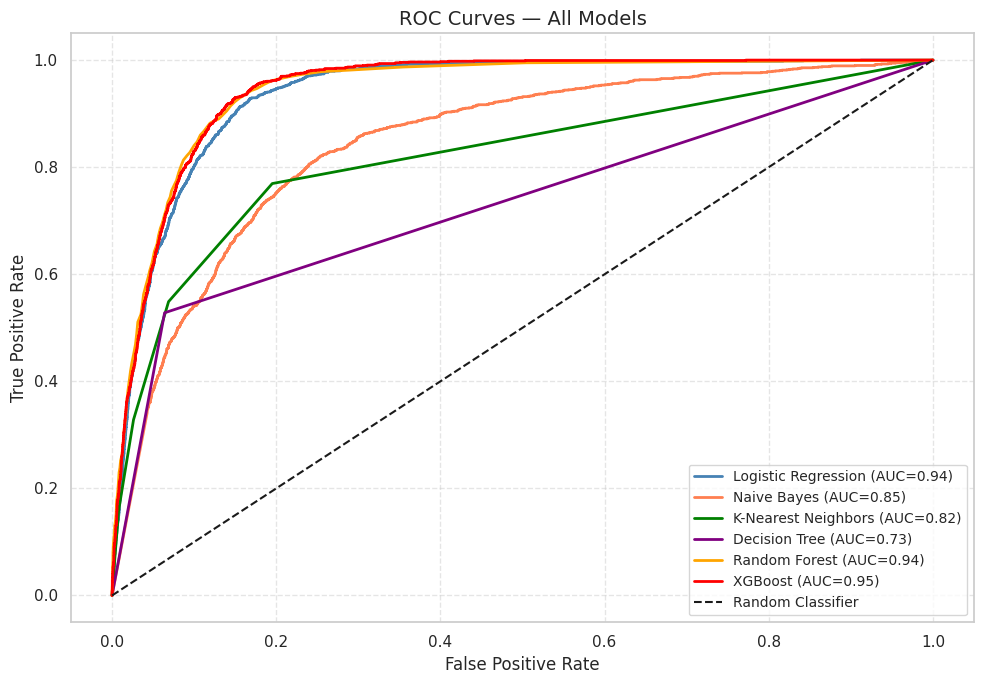

In [21]:
plt.figure(figsize=(10, 7))

colors = ['steelblue', 'coral', 'green',
          'purple', 'orange', 'red']

for (model_name, (auc, prob)), color in zip(roc_data.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.2f})',
             color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--',
         linewidth=1.5, label='Random Classifier')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — All Models", fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

FINAL MODEL COMPARISON SUMMARY


,Model,Accuracy,Precision,Recall,F1 Score,AUC
1,XGBoost,0.9141,0.6383,0.5489,0.5902,0.9453
2,Random Forest,0.9158,0.6739,0.4885,0.5664,0.9438
3,Decision Tree,0.8900,0.5115,0.5280,0.5196,0.7320
4,Logistic Regression,0.9120,0.6743,0.4224,0.5194,0.9383
5,Logistic Regression,0.9120,0.6743,0.4224,0.5194,0.9383
6,Naive Bayes,0.7569,0.2924,0.8154,0.4304,0.8454
7,K-Nearest Neighbors,0.9011,0.6142,0.3283,0.4279,0.8191


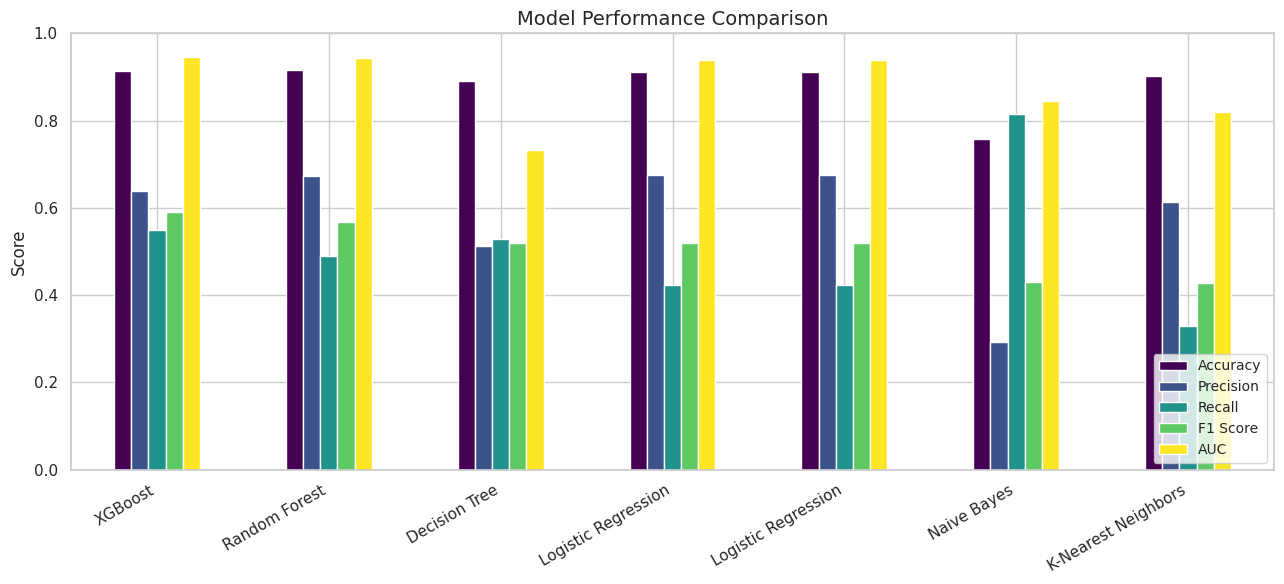


🏆 Best Model: XGBoost
   F1 Score : 0.5902
   AUC      : 0.9453


In [22]:
print("=" * 55)
print("FINAL MODEL COMPARISON SUMMARY")
print("=" * 55)

summary_df = pd.DataFrame(results_list)
summary_df = summary_df.sort_values(by="F1 Score",
                                     ascending=False)
summary_df = summary_df.reset_index(drop=True)
summary_df.index += 1

display(summary_df)

# Bar chart comparison
summary_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "AUC"]
].plot(kind="bar", figsize=(13, 6), colormap="viridis")

plt.title("Model Performance Comparison", fontsize=14)
plt.ylabel("Score", fontsize=12)
plt.xlabel("")
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

best_model = summary_df.iloc[0]["Model"]
best_f1    = summary_df.iloc[0]["F1 Score"]
best_auc   = summary_df.iloc[0]["AUC"]
print(f"\n🏆 Best Model: {best_model}")
print(f"   F1 Score : {best_f1:.4f}")
print(f"   AUC      : {best_auc:.4f}")

HYPERPARAMETER TUNING — EXTRA CREDIT

[1] Tuned Logistic Regression

  Logistic Regression (Tuned)
  Accuracy  : 0.8623
  Precision : 0.4450
  Recall    : 0.9009
  F1 Score  : 0.5957
  AUC       : 0.9396

  Classification Report:
              precision    recall  f1-score   support

          No       0.99      0.86      0.92     10965
         Yes       0.44      0.90      0.60      1392

    accuracy                           0.86     12357
   macro avg       0.72      0.88      0.76     12357
weighted avg       0.92      0.86      0.88     12357



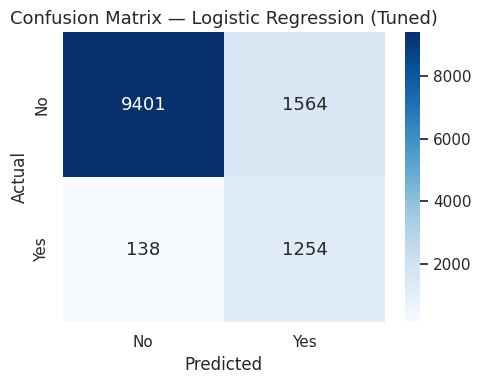


[2] Tuned Random Forest

  Random Forest (Tuned)
  Accuracy  : 0.8653
  Precision : 0.4521
  Recall    : 0.9231
  F1 Score  : 0.6070
  AUC       : 0.9459

  Classification Report:
              precision    recall  f1-score   support

          No       0.99      0.86      0.92     10965
         Yes       0.45      0.92      0.61      1392

    accuracy                           0.87     12357
   macro avg       0.72      0.89      0.76     12357
weighted avg       0.93      0.87      0.88     12357



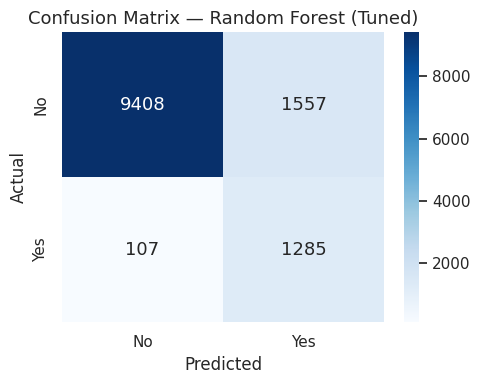


[3] Tuned XGBoost

  XGBoost (Tuned)
  Accuracy  : 0.8639
  Precision : 0.4495
  Recall    : 0.9274
  F1 Score  : 0.6055
  AUC       : 0.9493

  Classification Report:
              precision    recall  f1-score   support

          No       0.99      0.86      0.92     10965
         Yes       0.45      0.93      0.61      1392

    accuracy                           0.86     12357
   macro avg       0.72      0.89      0.76     12357
weighted avg       0.93      0.86      0.88     12357



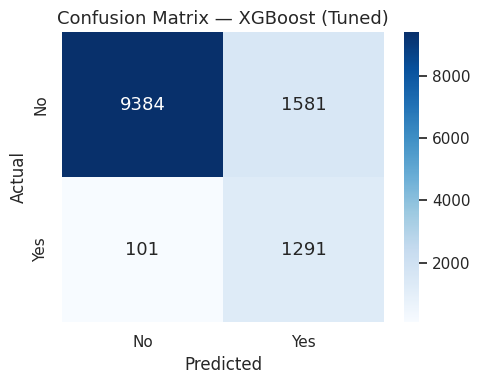


✓ Hyperparameter tuning complete.


In [23]:
print("=" * 55)
print("HYPERPARAMETER TUNING — EXTRA CREDIT")
print("=" * 55)

tuned_results = []

def evaluate_tuned(model, model_name, X_test, y_test, y_pred):
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  AUC       : {auc:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=['No', 'Yes']))
    plot_confusion_matrix(model_name, y_test, y_pred)

    tuned_results.append({
        "Model":     model_name,
        "Accuracy":  round(acc,  4),
        "Precision": round(prec, 4),
        "Recall":    round(rec,  4),
        "F1 Score":  round(f1,   4),
        "AUC":       round(auc,  4)
    })

# ── Tuned Logistic Regression ─────────────────────────────────
print("\n[1] Tuned Logistic Regression")
lr_tuned = LogisticRegression(
    C=0.1,
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr_tuned.fit(X_train_scaled, y_train)
y_pred_lr_tuned = lr_tuned.predict(X_test_scaled)
evaluate_tuned(lr_tuned, "Logistic Regression (Tuned)",
               X_test_scaled, y_test, y_pred_lr_tuned)

# ── Tuned Random Forest ───────────────────────────────────────
print("\n[2] Tuned Random Forest")
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)
rf_tuned.fit(X_train_scaled, y_train)
y_pred_rf_tuned = rf_tuned.predict(X_test_scaled)
evaluate_tuned(rf_tuned, "Random Forest (Tuned)",
               X_test_scaled, y_test, y_pred_rf_tuned)

# ── Tuned XGBoost ─────────────────────────────────────────────
print("\n[3] Tuned XGBoost")
xgb_tuned = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=7,
    eval_metric='logloss',
    random_state=42
)
xgb_tuned.fit(X_train_scaled, y_train)
y_pred_xgb_tuned = xgb_tuned.predict(X_test_scaled)
evaluate_tuned(xgb_tuned, "XGBoost (Tuned)",
               X_test_scaled, y_test, y_pred_xgb_tuned)

print("\n✓ Hyperparameter tuning complete.")

TUNED vs DEFAULT — COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression (Tuned),0.8623,0.4450,0.9009,0.5957,0.9396
1,Random Forest (Tuned),0.8653,0.4521,0.9231,0.6070,0.9459
2,XGBoost (Tuned),0.8639,0.4495,0.9274,0.6055,0.9493


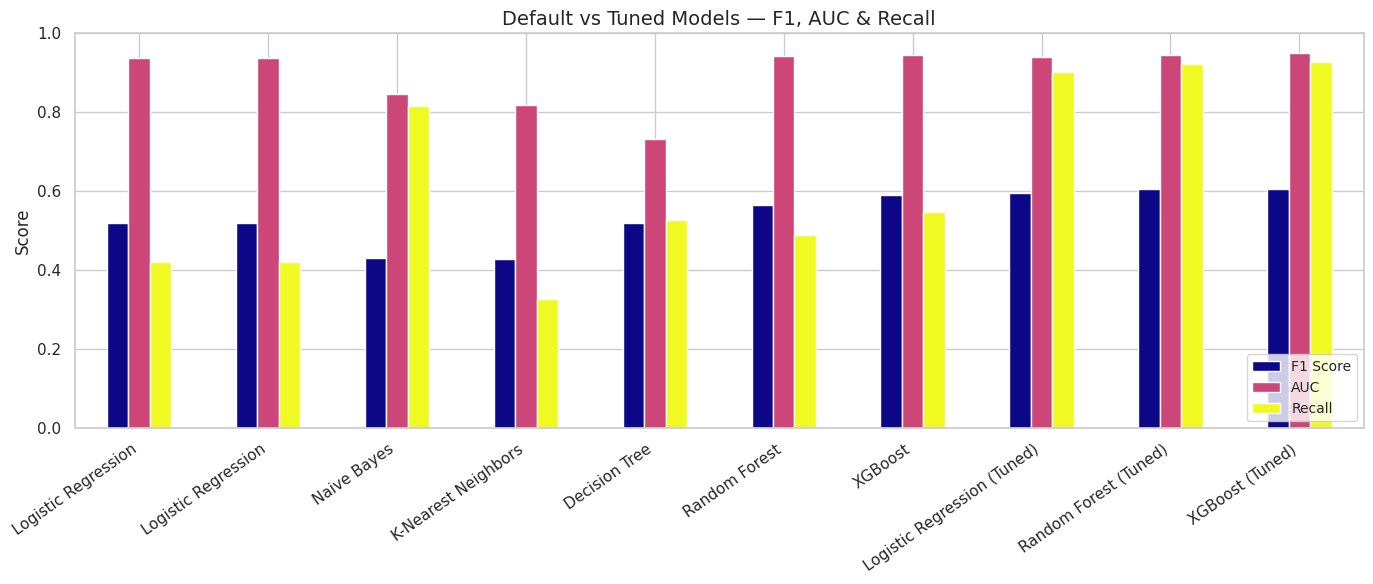


✓ Project Complete!


In [24]:
print("=" * 55)
print("TUNED vs DEFAULT — COMPARISON")
print("=" * 55)

tuned_df = pd.DataFrame(tuned_results)
display(tuned_df)

# Combined bar chart
combined = pd.DataFrame(results_list + tuned_results)
combined = combined.set_index("Model")

combined[["F1 Score", "AUC", "Recall"]].plot(
    kind="bar", figsize=(14, 6), colormap="plasma"
)
plt.title("Default vs Tuned Models — F1, AUC & Recall",
          fontsize=14)
plt.ylabel("Score", fontsize=12)
plt.xlabel("")
plt.xticks(rotation=35, ha='right')
plt.ylim(0, 1)
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

print("\n✓ Project Complete!")